<a href="https://colab.research.google.com/github/UH-GROUP-X/Hackathon26/blob/main/UH_GROUP_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hackathon 2026

# Setup file path and install packages

In [ ]:
# To get the training dataset from the Github.

import pandas as pd
datapath1 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_training.csv"
df1 = pd.read_csv(datapath1)
df1.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,45 - 54 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,65+ Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [ ]:
# To get the testing dataset from the Github.

import pandas as pd
datapath2 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_testing.csv"
df2 = pd.read_csv(datapath2)
df2.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,65+ Years,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,65+ Years,College Graduate,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,55 - 64 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35 - 44 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [ ]:
# To mount the google drive to later use it for saving the files.

from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [ ]:
!pip install -q xgboost lightgbm shap imbalanced-learn

# 1. Configuration

In [ ]:
# Configration for the submission files.

DRIVE_ROOT = '/content/drive/MyDrive/'
DATA_FOLDER = 'hackathon/'
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'

# To define the target and other variables.
TARGET_COL = 'covid_vaccine'
ID_COL = 'respondent_id'
TASK = 'classification'
RANDOM_STATE = 42

TRAIN_PATH = df1 # train
TEST_PATH  = df2 # test
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'
GROUP_NUMBER = 'X'

import os
os.makedirs(SUBMISSION_DIR, exist_ok=True)

print(f'Train      : {TRAIN_PATH}')
print(f'Test       : {TEST_PATH}')
print(f'Submissions: {SUBMISSION_DIR}')
print(f'Group      : {GROUP_NUMBER}')

Train      :       respondent_id  covid_concern  covid_knowledge  \
0                 1            3.0              1.0   
1                 2            2.0              1.0   
2                 3            0.0              2.0   
3                 4            2.0              2.0   
4                 5            1.0              1.0   
...             ...            ...              ...   
4751           4752            0.0              1.0   
4752           4753            2.0              1.0   
4753           4754            3.0              2.0   
4754           4755            1.0              2.0   
4755           4756            1.0              2.0   

      behavioral_antiviral_meds  behavioral_avoidance  behavioral_face_mask  \
0                           0.0                   1.0                   0.0   
1                           0.0                   1.0                   0.0   
2                           0.0                   0.0                   0.0   
3         

# 2. Imports

In [ ]:
# To import all the important libraries.

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# libraries for the Pre-processing.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import ( StandardScaler, RobustScaler, LabelEncoder,
                                    OneHotEncoder, OrdinalEncoder)

# To import all the Models.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# For Evaluation.
from sklearn.model_selection import ( train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.metrics import ( accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

# For XAI.
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
pd.set_option('display.max_columns', 40)

# 3. Load data

In [ ]:
# To load the data.

train_raw = pd.read_csv(datapath1)
test_raw  = pd.read_csv(datapath2)

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
train_raw.head()

Train : 4,756 rows × 31 columns
Test  : 4,749 rows × 30 columns


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,45 - 54 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,65+ Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


# 4. Exploratory Data Analysis (EDA)

In [ ]:
# To get the overview.

train_raw.info()
print()
display(train_raw.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 4624 non-null   float64
 13  hea

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
covid_concern,4744.0,NaN,NaN,NaN,1.648609,0.903204,0.0,1.0,2.0,2.0,3.0
covid_knowledge,4729.0,NaN,NaN,NaN,1.296469,0.615705,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.053353,0.22476,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,NaN,NaN,NaN,0.733347,0.442256,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4754.0,NaN,NaN,NaN,0.072991,0.260149,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4747.0,NaN,NaN,NaN,0.839267,0.367323,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4746.0,NaN,NaN,NaN,0.3563,0.478956,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4742.0,NaN,NaN,NaN,0.329186,0.469967,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4735.0,NaN,NaN,NaN,0.693981,0.460886,0.0,0.0,1.0,1.0,1.0


## 4.1. Missing values.

,Count,Pct (%)
employment_sector,2330,48.99
health_insurance,1908,40.12
income_poverty,748,15.73
rent_or_own,329,6.92
employment_status,238,5.00
marital_status,231,4.86
education,228,4.79
chronic_med_condition,169,3.55
child_under_6_months,135,2.84
health_worker,132,2.78


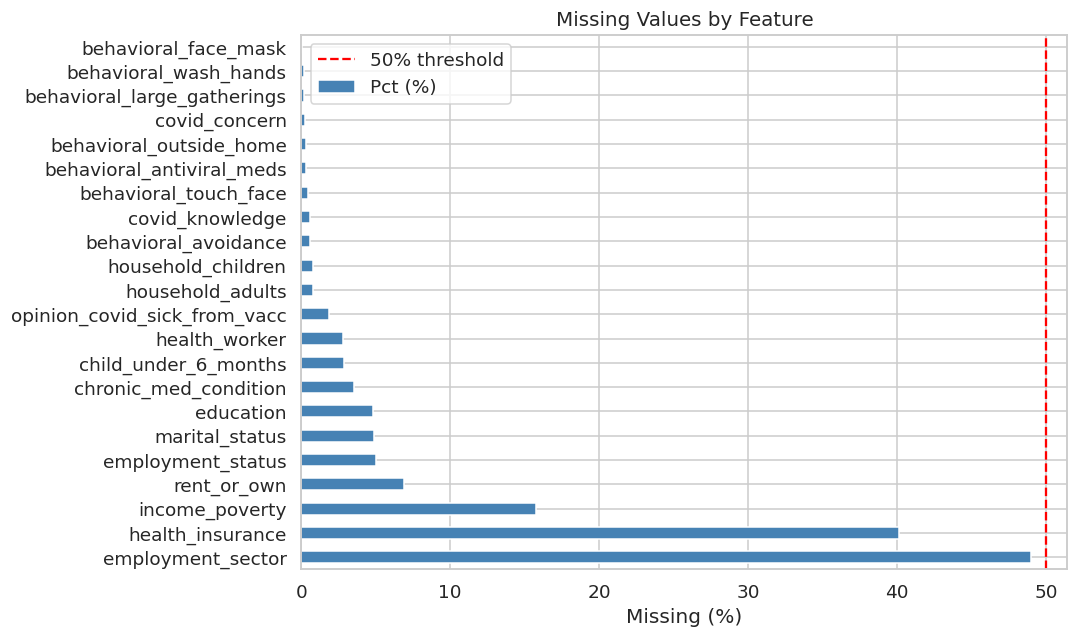

Key observations:
  employment_sector : 49.0% missing — nearly half the dataset
  health_insurance  : 40.1% missing
  income_poverty    : 15.7% missing


In [ ]:
missing = train_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Pct (%)'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature')
ax.legend()
plt.tight_layout()
plt.show()

# Key observations
print('Key observations:')
print(f'  employment_sector : {train_raw["employment_sector"].isnull().mean()*100:.1f}% missing — nearly half the dataset')
print(f'  health_insurance  : {train_raw["health_insurance"].isnull().mean()*100:.1f}% missing')
print(f'  income_poverty    : {train_raw["income_poverty"].isnull().mean()*100:.1f}% missing')

## 4.2 Target variable distribution.

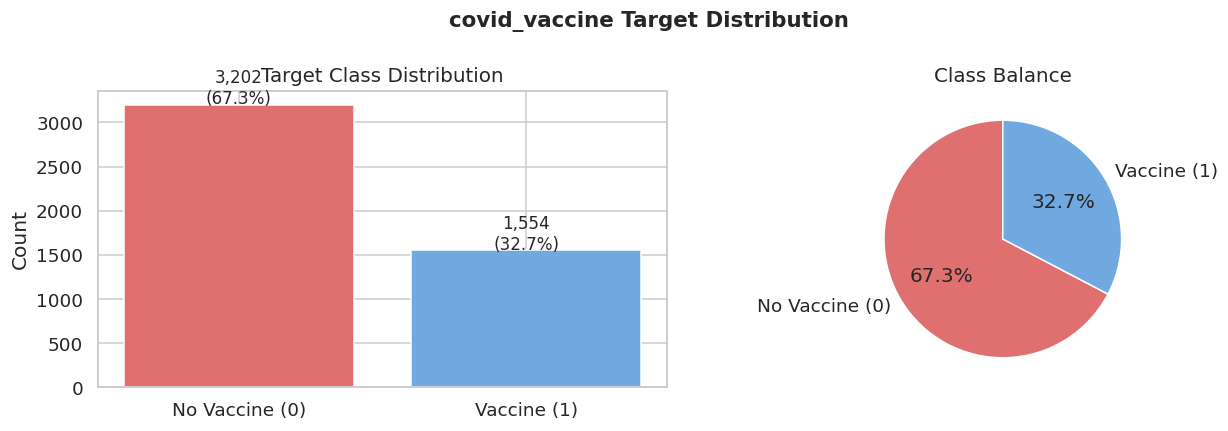

Class balance ratio: 0.485  (1.0 = perfectly balanced)
Imbalance note: ~67% did NOT get the vaccine — use class_weight="balanced"


In [ ]:
vc = train_raw[TARGET_COL].value_counts()
labels = ['No Vaccine (0)', 'Vaccine (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(labels, vc.values, color=['#e07070', '#70a8e0'])
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:,}\n({v/len(train_raw)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%',
            colors=['#e07070','#70a8e0'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('covid_vaccine Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

balance = vc.min() / vc.max()
print(f'Class balance ratio: {balance:.3f}  (1.0 = perfectly balanced)')
print(f'Imbalance note: ~{vc[0]/len(train_raw)*100:.0f}% did NOT get the vaccine — use class_weight="balanced"')

## 4.3 Numeric Feature Distributions

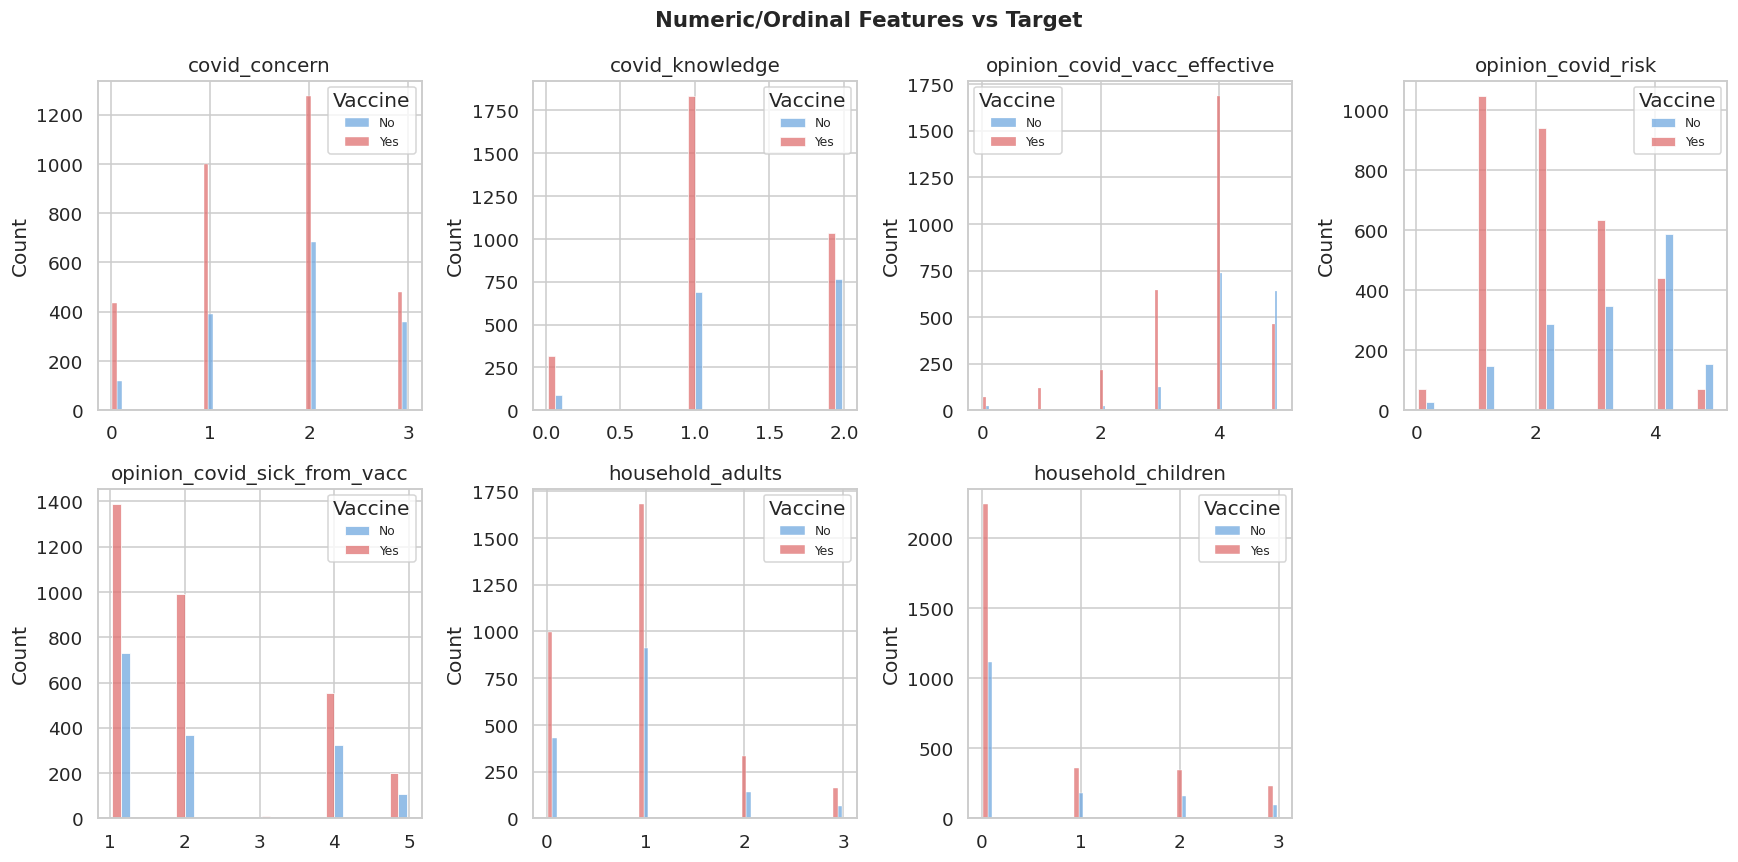

In [55]:
# These are the truly numeric/ordinal columns
num_cols = [ 'covid_concern', 'covid_knowledge',
             'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc',
             'household_adults', 'household_children']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_raw, x=col, hue=TARGET_COL,
                 multiple='dodge', ax=axes[i], palette={0:'#e07070', 1:'#70a8e0'},
                 shrink=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(title='Vaccine', labels=['No','Yes'], fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numeric/Ordinal Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.4 Binary Feature Vaccination Rates

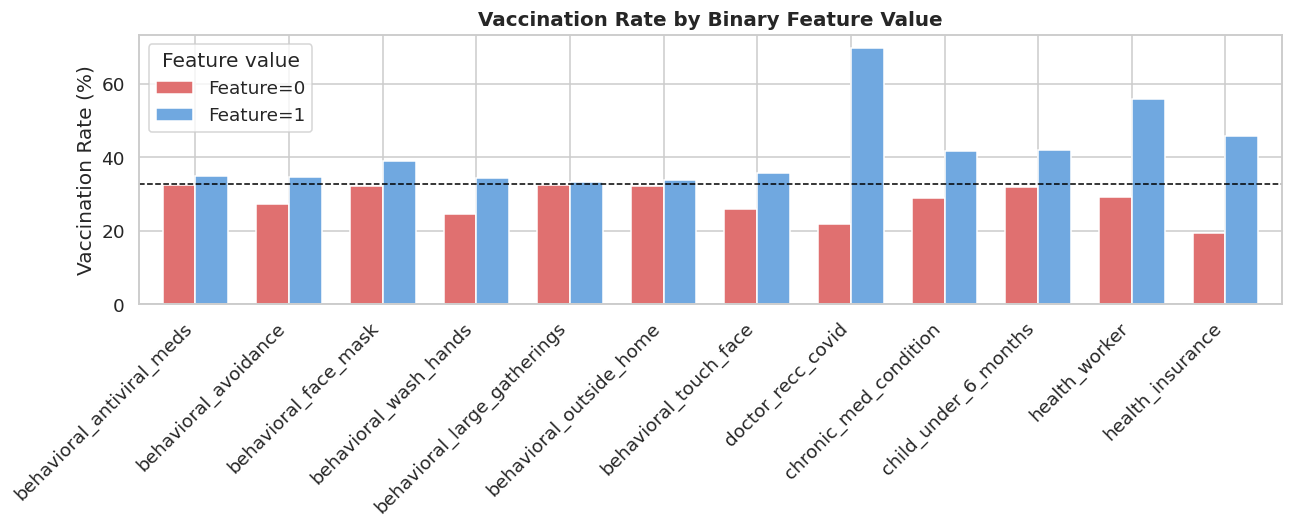

Biggest impact features (difference in vaccination rate):
doctor_recc_covid              48.150414
health_worker                  26.754892
health_insurance               26.386130
chronic_med_condition          12.777911
child_under_6_months           10.014453
behavioral_touch_face           9.916424
behavioral_wash_hands           9.622468
behavioral_avoidance            7.242837
behavioral_face_mask            6.728816
behavioral_antiviral_meds       2.258661
behavioral_outside_home         1.664773
behavioral_large_gatherings     0.861614


In [56]:
binary_cols = [ 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
                'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
                'behavioral_touch_face', 'doctor_recc_covid', 'chronic_med_condition',
                'child_under_6_months', 'health_worker', 'health_insurance']

# Vaccination rate when feature = 1 vs 0
rates = {}
for col in binary_cols:
    r0 = train_raw[train_raw[col] == 0][TARGET_COL].mean()
    r1 = train_raw[train_raw[col] == 1][TARGET_COL].mean()
    rates[col] = {'Feature=0': r0, 'Feature=1': r1}

rates_df = pd.DataFrame(rates).T * 100

fig, ax = plt.subplots(figsize=(12, 5))
rates_df.plot(kind='bar', ax=ax, color=['#e07070', '#70a8e0'], width=0.7)
ax.set_ylabel('Vaccination Rate (%)')
ax.set_title('Vaccination Rate by Binary Feature Value', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Feature value')
ax.axhline(train_raw[TARGET_COL].mean()*100, color='black',
           linestyle='--', linewidth=1, label='Overall average')
plt.tight_layout()
plt.show()

print('Biggest impact features (difference in vaccination rate):')
rates_df['diff'] = (rates_df['Feature=1'] - rates_df['Feature=0']).abs()
print(rates_df['diff'].sort_values(ascending=False).to_string())

## 4.5 Categorical Feature Vaccination Rates

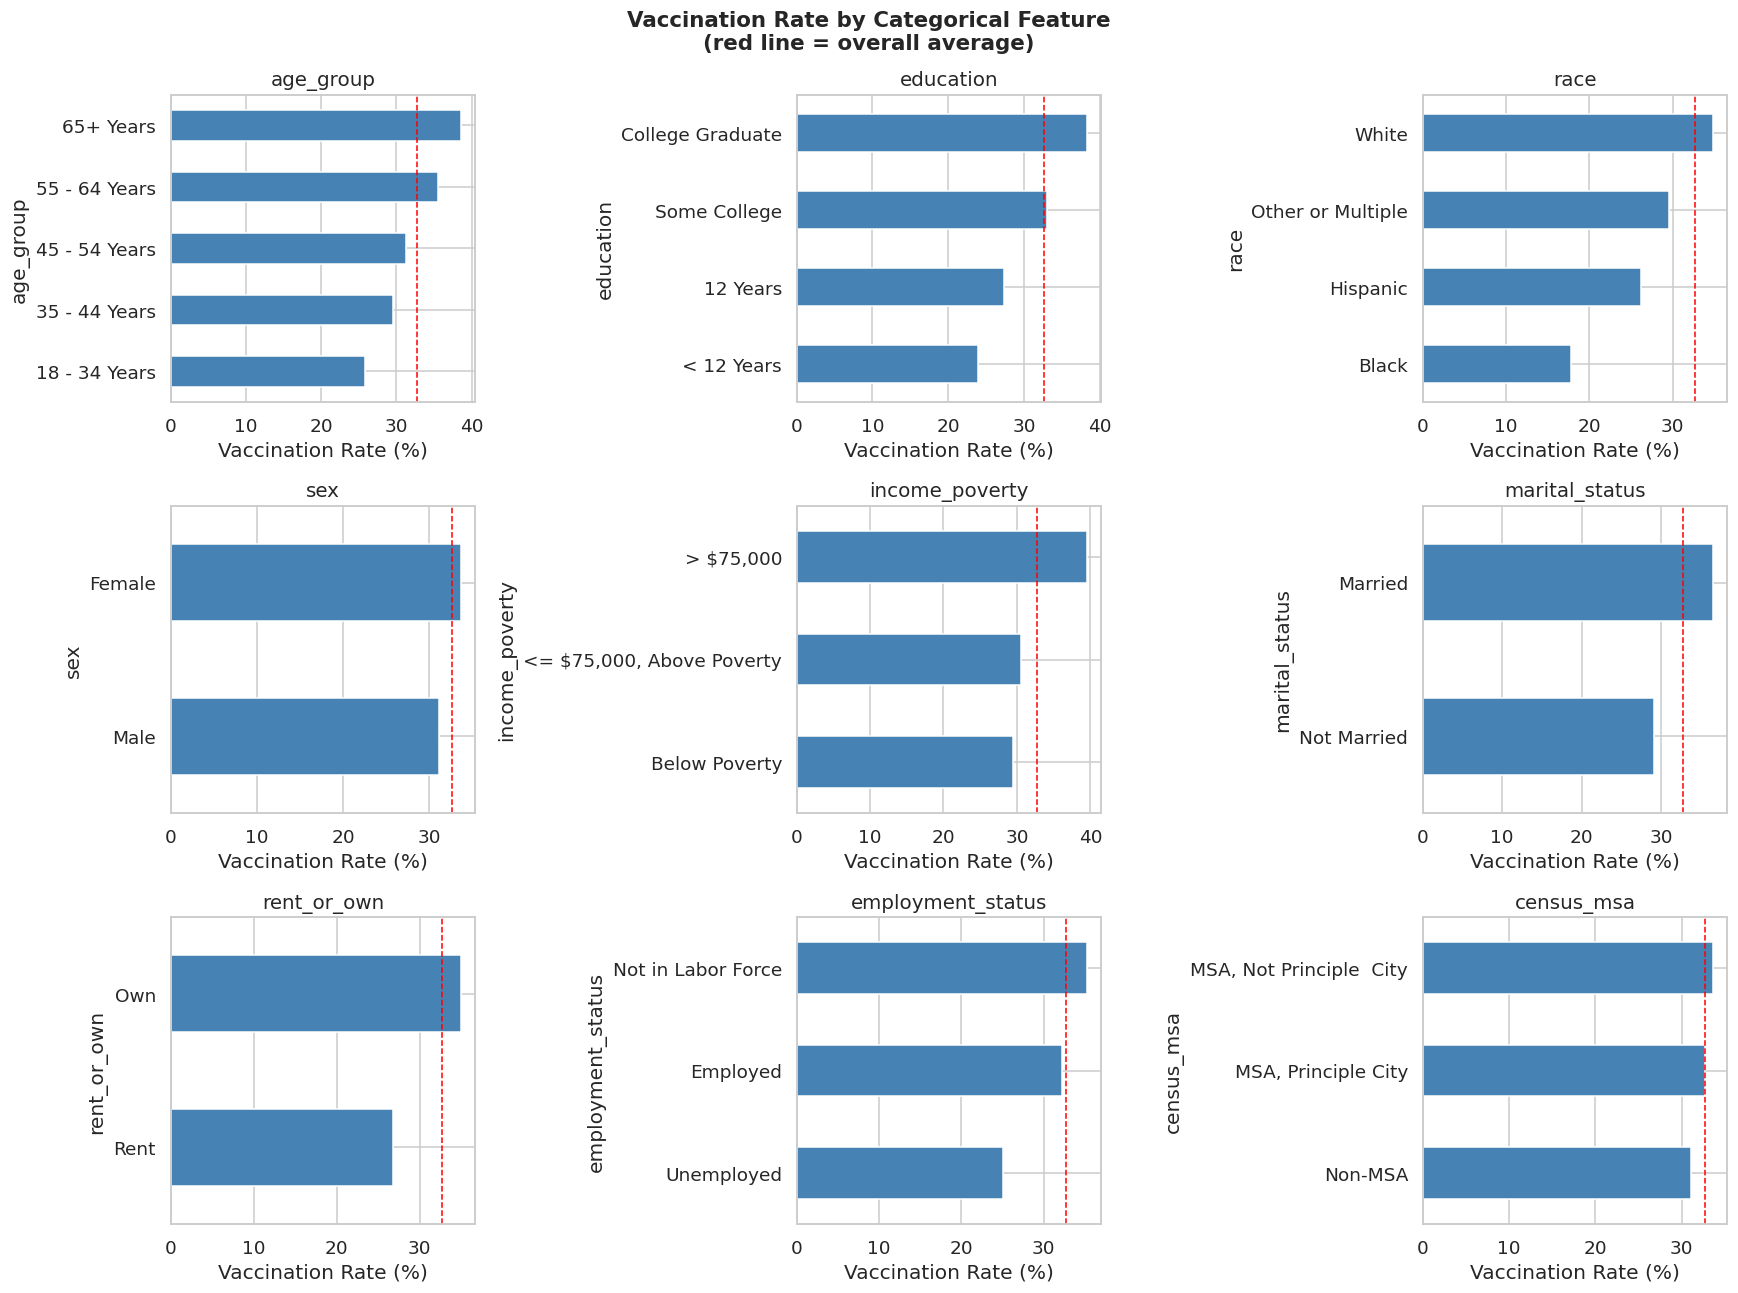

In [57]:
cat_cols = [
    'age_group', 'education', 'race', 'sex',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'census_msa'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = train_raw.groupby(col)[TARGET_COL].mean().sort_values() * 100
    rate.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].axvline(train_raw[TARGET_COL].mean()*100, color='red',
                    linestyle='--', linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel('Vaccination Rate (%)')

plt.suptitle('Vaccination Rate by Categorical Feature\n(red line = overall average)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.6 Correlation Heatmap (Numeric Features)

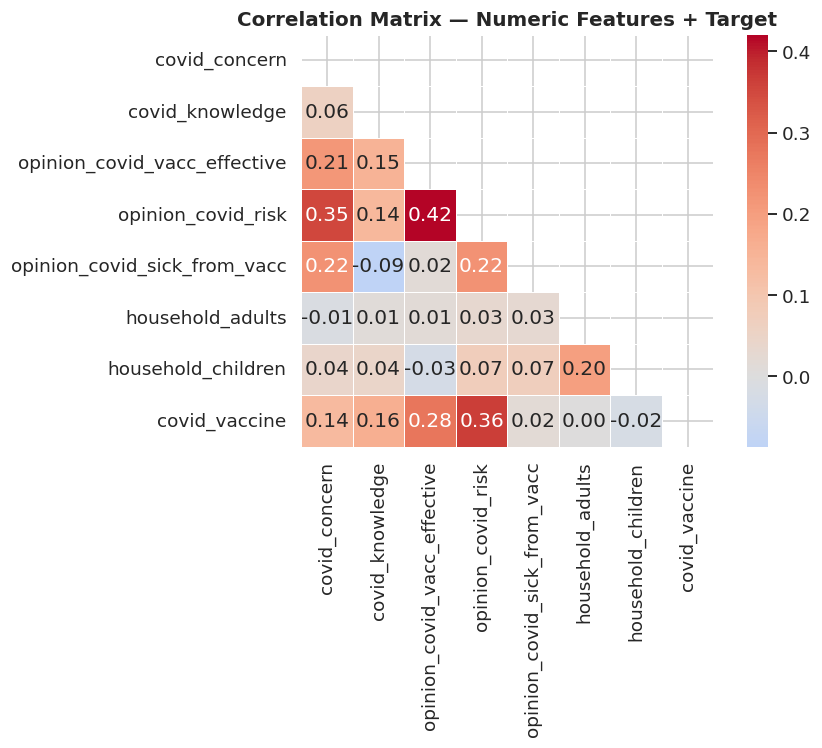

Correlation with target (sorted by absolute value):


,|corr with target|
opinion_covid_risk,0.364942
opinion_covid_vacc_effective,0.277309
covid_knowledge,0.164260
covid_concern,0.135191
household_children,0.021661
opinion_covid_sick_from_vacc,0.019444
household_adults,0.002741


In [58]:
corr_cols = num_cols + [TARGET_COL]
corr = train_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with target (sorted by absolute value):')
display(corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).to_frame('|corr with target|'))

## 4.7 Doctor Recommendation — Key Predictor Deep Dive

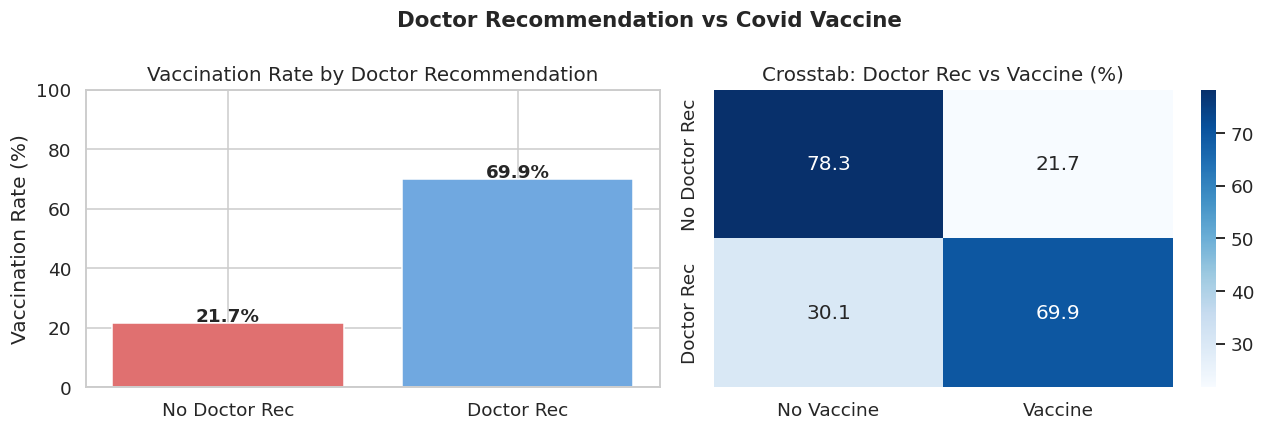

In [59]:
# Doctor recommendation is expected to be the strongest predictor
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vaccination rate by doctor recommendation
doc_rates = train_raw.groupby('doctor_recc_covid')[TARGET_COL].mean() * 100
doc_rates.index = ['No Doctor Rec', 'Doctor Rec']
bars = axes[0].bar(doc_rates.index, doc_rates.values, color=['#e07070','#70a8e0'])
for bar, v in zip(bars, doc_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Vaccination Rate by Doctor Recommendation')
axes[0].set_ylabel('Vaccination Rate (%)')
axes[0].set_ylim(0, 100)

# Crosstab heatmap
ct = pd.crosstab(train_raw['doctor_recc_covid'],
                 train_raw[TARGET_COL], normalize='index') * 100
ct.index = ['No Doctor Rec', 'Doctor Rec']
ct.columns = ['No Vaccine', 'Vaccine']
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Crosstab: Doctor Rec vs Vaccine (%)')

plt.suptitle('Doctor Recommendation vs Covid Vaccine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.8 Opinion Features Deep Dive

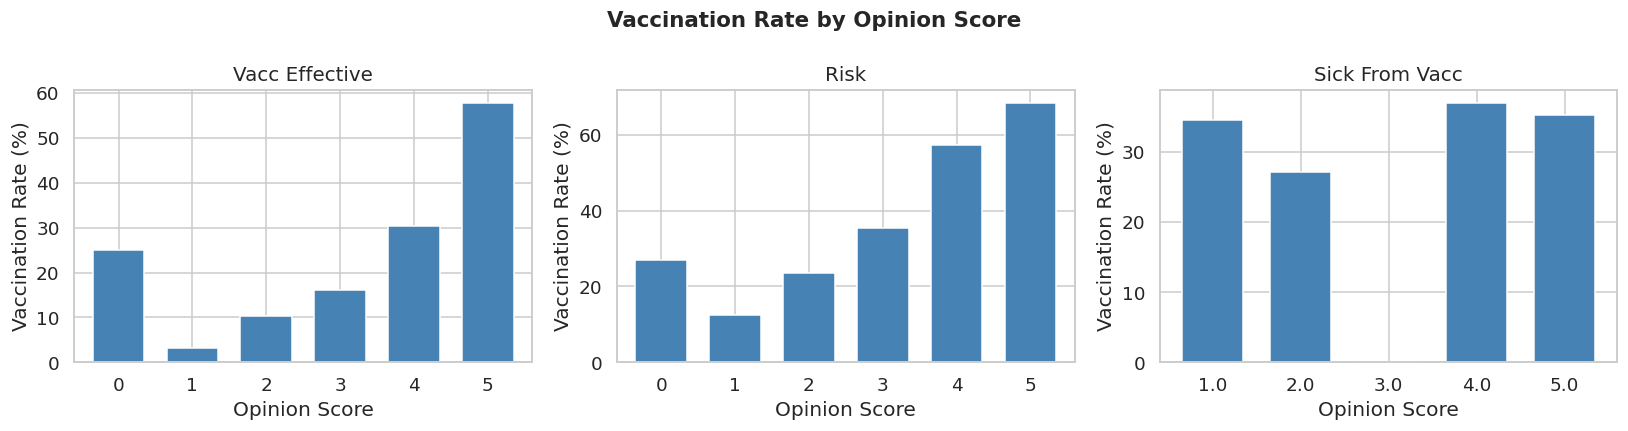

In [60]:
opinion_cols = ['opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(opinion_cols):
    rate = train_raw.groupby(col)[TARGET_COL].mean() * 100
    rate.plot(kind='bar', ax=axes[i], color='steelblue', width=0.7)
    axes[i].set_title(col.replace('opinion_covid_', '').replace('_', ' ').title())
    axes[i].set_ylabel('Vaccination Rate (%)')
    axes[i].set_xlabel('Opinion Score')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Vaccination Rate by Opinion Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.9 Missing Value Pattern Analysis

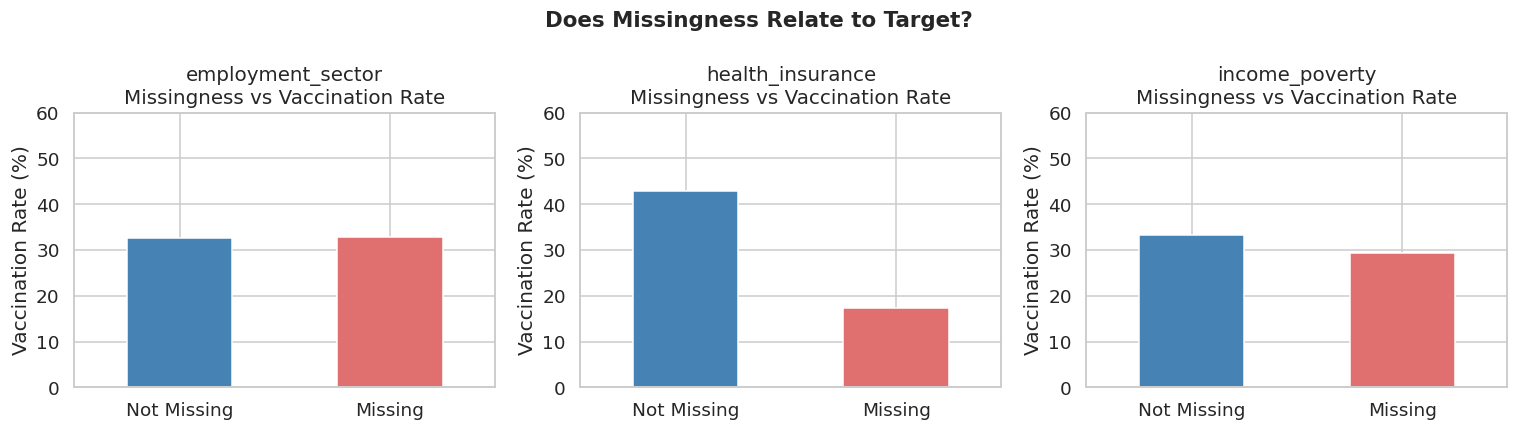

If bars differ: missingness is informative — consider adding a "missing indicator" feature


In [61]:
# Check if missingness in key columns is related to target
high_miss_cols = ['employment_sector', 'health_insurance', 'income_poverty']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(high_miss_cols):
    miss_flag = train_raw[col].isnull().astype(int)
    rate = train_raw.groupby(miss_flag)[TARGET_COL].mean() * 100
    rate.index = ['Not Missing', 'Missing']
    rate.plot(kind='bar', ax=axes[i], color=['steelblue','#e07070'], width=0.5)
    axes[i].set_title(f'{col}\nMissingness vs Vaccination Rate')
    axes[i].set_ylabel('Vaccination Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].set_ylim(0, 60)

plt.suptitle('Does Missingness Relate to Target?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('If bars differ: missingness is informative — consider adding a "missing indicator" feature')

# 5. Pre-processing

### 5.1 Feature Engineering — Missing Indicators


In [62]:
def add_missing_indicators(df, cols):
    """Add binary flag columns for high-missing features."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    return df

# Add missing indicators for columns with high missingness
HIGH_MISS_COLS = ['employment_sector', 'health_insurance', 'income_poverty', 'marital_status']

train_fe = add_missing_indicators(train_raw, HIGH_MISS_COLS)
test_fe  = add_missing_indicators(test_raw,  HIGH_MISS_COLS)

print('New indicator columns added:')
new_cols = [f'{c}_missing' for c in HIGH_MISS_COLS]
print(new_cols)
display(train_fe[new_cols].sum().to_frame('# Missing flagged'))

New indicator columns added:
['employment_sector_missing', 'health_insurance_missing', 'income_poverty_missing', 'marital_status_missing']


,# Missing flagged
employment_sector_missing,2330
health_insurance_missing,1908
income_poverty_missing,748
marital_status_missing,231


5.2 Separate Features & Target — Train/Val Split

In [64]:
X_all = train_fe.drop(columns=[TARGET_COL, ID_COL])
y_all = train_fe[TARGET_COL].copy()

test_ids   = test_fe[ID_COL].copy()
X_test_raw = test_fe.drop(columns=[ID_COL])

# 80/20 stratified split (preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f'X_train : {X_train.shape}   y_train: {y_train.value_counts().to_dict()}')
print(f'X_val   : {X_val.shape}     y_val  : {y_val.value_counts().to_dict()}')
print(f'X_test  : {X_test_raw.shape}')

X_train : (3804, 33)   y_train: {0: 2561, 1: 1243}
X_val   : (952, 33)     y_val  : {0: 641, 1: 311}
X_test  : (4749, 33)


5.3 Define Feature Groups

In [65]:
# ── Numeric/ordinal: impute with median, scale ────────────────────────────
numeric_features = [
    'covid_concern', 'covid_knowledge',
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
    'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months',
    'health_worker', 'health_insurance',
    'household_adults', 'household_children',
    'doctor_recc_covid',
    'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc',
    # missing indicators
    'employment_sector_missing', 'health_insurance_missing',
    'income_poverty_missing', 'marital_status_missing'
]

# Keep only columns that actually exist after feature engineering
numeric_features = [c for c in numeric_features if c in X_train.columns]

# ── Categorical: impute with 'Unknown', one-hot encode ────────────────────
categorical_features = [
    'age_group', 'education', 'race', 'sex',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'census_msa', 'employment_sector'
]
categorical_features = [c for c in categorical_features if c in X_train.columns]

print(f'Numeric features   ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features   (23): ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc', 'employment_sector_missing', 'health_insurance_missing', 'income_poverty_missing', 'marital_status_missing']
Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


5.4 Build Two Preprocessing Pipelines A and B


In [66]:
# ══════════════════════════════════════════════════════════════════════════
#  VERSION A — Median imputation + StandardScaler (default)
# ══════════════════════════════════════════════════════════════════════════
num_pipe_A = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe_A = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor_A = ColumnTransformer([
    ('num', num_pipe_A, numeric_features),
    ('cat', cat_pipe_A, categorical_features),
], remainder='drop')

# ══════════════════════════════════════════════════════════════════════════
#  VERSION B — Most frequent imputation + RobustScaler (better for outliers)
# ══════════════════════════════════════════════════════════════════════════
num_pipe_B = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  RobustScaler()),
])
cat_pipe_B = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor_B = ColumnTransformer([
    ('num', num_pipe_B, numeric_features),
    ('cat', cat_pipe_B, categorical_features),
], remainder='drop')

# Fit on training data ONLY
preprocessor_A.fit(X_train)
preprocessor_B.fit(X_train)

X_train_A = preprocessor_A.transform(X_train)
X_val_A   = preprocessor_A.transform(X_val)
X_test_A  = preprocessor_A.transform(X_test_raw)

X_train_B = preprocessor_B.transform(X_train)
X_val_B   = preprocessor_B.transform(X_val)
X_test_B  = preprocessor_B.transform(X_test_raw)

print(f'Version A processed shape: {X_train_A.shape}')
print(f'Version B processed shape: {X_train_B.shape}')




Version A processed shape: (3804, 78)
Version B processed shape: (3804, 78)


5.5 Select Active Preprocessing Version

In [67]:
# Change to 'B' if Version B gives better results after model comparison
PREP_VERSION = 'A'

if PREP_VERSION == 'A':
    X_train_proc = X_train_A
    X_val_proc   = X_val_A
    X_test_proc  = X_test_A
    active_prep  = preprocessor_A
else:
    X_train_proc = X_train_B
    X_val_proc   = X_val_B
    X_test_proc  = X_test_B
    active_prep  = preprocessor_B

# Build feature name list (needed later for XAI)
try:
    ohe_names = active_prep.named_transformers_['cat']['encoder'] \
                .get_feature_names_out(categorical_features).tolist()
except Exception:
    ohe_names = []
feature_names = numeric_features + ohe_names

print(f'Active preprocessing: Version {PREP_VERSION}')
print(f'Total features after encoding: {len(feature_names)}')

def evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val):
    model.fit(X_train_proc, y_train)
    preds = model.predict(X_val_proc)
    proba = model.predict_proba(X_val_proc)[:, 1]

    acc  = accuracy_score(y_val, preds)
    f1   = f1_score(y_val, preds)
    prec = precision_score(y_val, preds)
    rec  = recall_score(y_val, preds)
    auc  = roc_auc_score(y_val, proba)

    print("\n===== MODEL PERFORMANCE =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print("=============================\n")

    return preds, acc, f1, auc

Active preprocessing: Version A
Total features after encoding: 78


# 6. Modelling & Cross-Validation Benchmark

6.1. Logistic Regression — Submission Code


In [68]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

# Evaluate
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Fit on full training
model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

# Save submission
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: preds
})

filename = f"{SUBMISSION_DIR}challenge_submission_group_{GROUP_NUMBER}_order_1_logreg.csv"
submission.to_csv(filename, index=False)

print("Saved:", filename)
print(f"Logistic Regression — AUC={auc:.4f}, F1={f1:.4f}")




===== MODEL PERFORMANCE =====
Accuracy : 0.7773
Precision: 0.6286
Recall   : 0.7781
F1 Score : 0.6954
AUC      : 0.8609

Saved: /content/drive/MyDrive/hackathon/submissions/challenge_submission_group_X_order_1_logreg.csv
Logistic Regression — AUC=0.8609, F1=0.6954


6.2 Decision Tree

In [69]:
model = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: preds
})

filename = f"{SUBMISSION_DIR}challenge_submission_group_{GROUP_NUMBER}_order_2_decisiontree.csv"
submission.to_csv(filename, index=False)

print("Saved:", filename)
print(f"Decision Tree — AUC={auc:.4f}, F1={f1:.4f}")



===== MODEL PERFORMANCE =====
Accuracy : 0.7500
Precision: 0.5953
Recall   : 0.7331
F1 Score : 0.6571
AUC      : 0.7914

Saved: /content/drive/MyDrive/hackathon/submissions/challenge_submission_group_X_order_2_decisiontree.csv
Decision Tree — AUC=0.7914, F1=0.6571


6.3. Random Forest

In [70]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: preds
})

filename = f"{SUBMISSION_DIR}challenge_submission_group_{GROUP_NUMBER}_order_3_randomforest.csv"
submission.to_csv(filename, index=False)

print("Saved:", filename)
print(f"Random Forest — AUC={auc:.4f}, F1={f1:.4f}")



===== MODEL PERFORMANCE =====
Accuracy : 0.8036
Precision: 0.7650
Recall   : 0.5756
F1 Score : 0.6569
AUC      : 0.8458

Saved: /content/drive/MyDrive/hackathon/submissions/challenge_submission_group_X_order_3_randomforest.csv
Random Forest — AUC=0.8458, F1=0.6569


# 7. Hyper-parameter Tuning

In [ ]:
# Auto-picks best; override like: TUNE_MODEL = 'Random Forest'
TUNE_MODEL    = best_so_far
N_ITER_SEARCH = 40

param_grids = {
    'Logistic Regression': {
        'C':       [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver':  ['liblinear', 'saga'],
    },
    'Decision Tree': {
        'max_depth':         [3, 5, 8, 12, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf':  [1, 2, 4, 8],
    },
    'Random Forest': {
        'n_estimators':      [100, 200, 400],
        'max_depth':         [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2', 0.3],
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200, 400],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5, 6],
        'subsample':     [0.6, 0.8, 1.0],
    },
    'XGBoost': {
        'n_estimators':     [100, 200, 400],
        'learning_rate':    [0.01, 0.05, 0.1],
        'max_depth':        [3, 5, 7],
        'subsample':        [0.6, 0.8, 1.0],
        'colsample_bytree': [0.5, 0.7, 1.0],
        'reg_alpha':        [0, 0.1, 1],
    },
    'LightGBM': {
        'n_estimators':      [100, 200, 400],
        'learning_rate':     [0.01, 0.05, 0.1],
        'num_leaves':        [15, 31, 63],
        'subsample':         [0.6, 0.8, 1.0],
        'min_child_samples': [10, 20, 50],
    },
    'KNN': {
        'n_neighbors': [5, 7, 11, 15, 21],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
}

param_grid = param_grids.get(TUNE_MODEL)
print(f'Tuning: {TUNE_MODEL}')

if param_grid:
    search = RandomizedSearchCV(
        models[TUNE_MODEL], param_grid,
        n_iter=N_ITER_SEARCH, cv=cv,
        scoring='roc_auc', n_jobs=-1,
        random_state=RANDOM_STATE, verbose=1
    )
    search.fit(X_train_proc, y_train)
    best_model = search.best_estimator_

    print(f'\nBest params : {search.best_params_}')
    print(f'Best CV AUC : {search.best_score_:.4f}')

    proba_tuned = best_model.predict_proba(X_val_proc)[:, 1]
    tuned_auc   = roc_auc_score(y_val, proba_tuned)
    prev_auc    = val_results[TUNE_MODEL]['AUC']
    print(f'\nVal AUC before tuning: {prev_auc:.4f}')
    print(f'Val AUC after tuning : {tuned_auc:.4f}  ({tuned_auc - prev_auc:+.4f})')

    trained_models[f'{TUNE_MODEL} (tuned)'] = best_model

NameError: name 'best_so_far' is not defined

# 8. Feature Importance

# 9. Explainable AI (XAI) with SHAP

# 10. Submission Files

# 11. Final Summary Dashboard